### Atelier Matplotlib 

##### Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. 
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, 
la consommation énergétique, l'état du capteur, le bâtiment, la date et l'heure de la mesure. 
Après avoir utilisé NumPy pour manipuler les données numériques et Pandas pour importer, 
nettoyer et analyser le dataset, l'étape suivante consiste à représenter graphiquement les 
informations afin d'identifier des tendances, des différences entre bâtiments et des anomalies. 

##### Structuration du projet 

In [2]:
# Importation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\cissc\OneDrive\Documents\P1IA_ODC\ATL_Matplotlib\data\mesures_capteurs.csv')
# On ajoute un 'r' devant les guillemets pour éviter les erreurs de caractères)

In [4]:
df.head(3)

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK


#### Partie 1 – Graphique linéaire (Line Plot)

##### 1) Affichage de l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

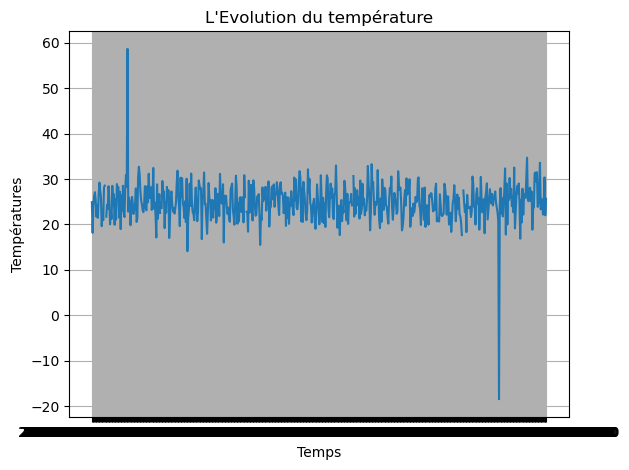

In [5]:
df_tries = df.sort_values('date_heure')

plt.figure()

plt.plot(df_tries['date_heure'], df_tries['temperature'])
plt.grid()
plt.xlabel('Temps')
plt.ylabel('Températures')
plt.title("L'Evolution du température")

plt.tight_layout()
plt.show()

##### 2) Identifions visuellement les valeurs qui semblent anormales. 
On peut remarquer visuellement que les températures prochent de -20 et 60 sont anormales

#### Partie 2 – Diagramme en barres (Bar Chart) 

##### 1) Détermination de la consommation_batiment qui stocke les consommations moyennes des bâtiments 

In [6]:
consommation_batiment = df.groupby(df['batiment'])['consommation'].mean()
consommation_batiment

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

##### 2) Comparons graphiquement la consommation moyenne des bâtiments 

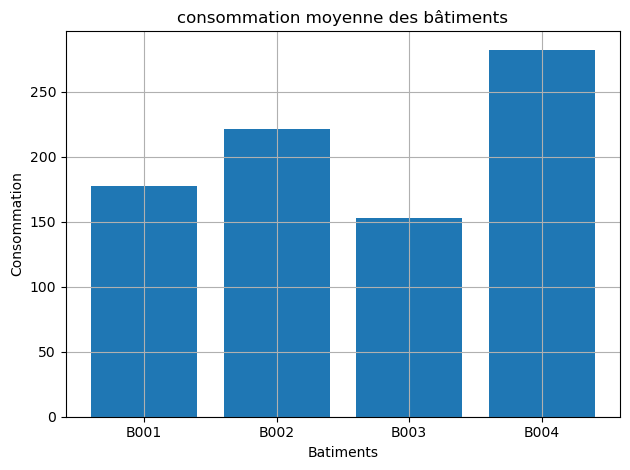

In [7]:
plt.figure()

plt.bar(consommation_batiment.index, consommation_batiment.values)
plt.grid()
plt.xlabel('Batiments')
plt.ylabel('Consommation')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

Note : On constate bien que le batiment 'B004' a le taux de consommation d'energie le plus élevé Par contre le batiment 'B003' a le plus
faible taux de consommation 

##### 3) Comparons la consommation moyenne des bâtiments avec un graphique horizontal

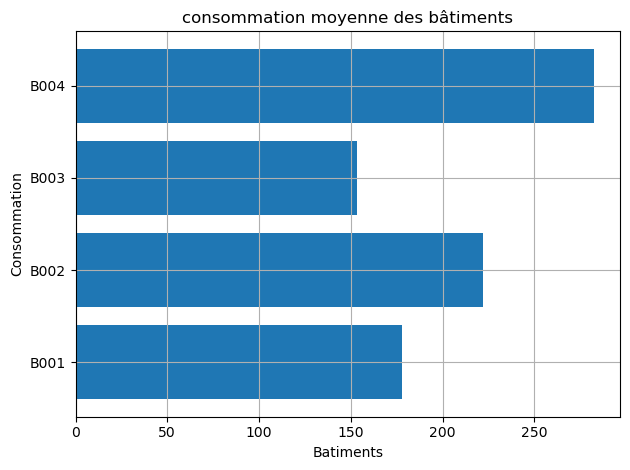

In [8]:
plt.figure()

plt.barh(consommation_batiment.index, consommation_batiment.values)
plt.grid()
plt.xlabel('Batiments')
plt.ylabel('Consommation')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

Note : On peut remarquer la meme chose avec le graphique horizonjtale

##### 4) Dans quels cas un graphique horizontal peut-il être plus lisible ? 
Un graphique horizontal peut etre beaucoup plus lisible quand on a plusieurs variables (ici batiments)

##### Partie 3 – Histogramme 

##### 1) Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille 

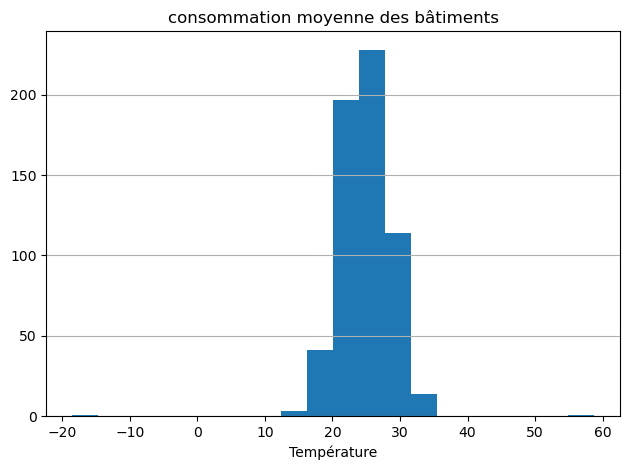

In [9]:
plt.figure()

plt.hist(df['temperature'], bins = 20)
plt.grid(axis = 'y')
plt.xlabel('Température')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

##### 2) Analyse du graphique pour voir 

        a) où se concentrent les températures 
        b) si la distribution semble symétrique  
        c) s'il existe des valeurs très éloignées 
        d) si des valeurs aberrantes sont visibles

a) On voit que les températures se concentrent plus dans l'intervalle 20 et 30 degrés 

b) Oui la distribution semble bien symétrique

c) Oui il existe des valeurs trés éloignées au alentour de -20 et 60

d) Les valeurs aberrantes sont visibles sur le graphe

##### 3) Affichage la distribution de la consommation en divisant la plage des données en 20 classes

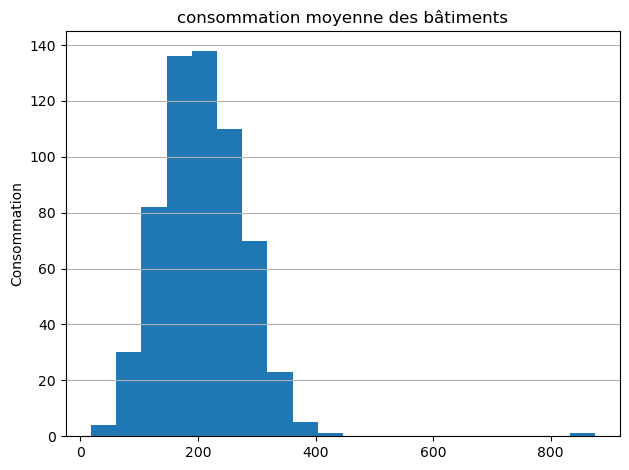

In [10]:
plt.figure()

plt.hist(df['consommation'], bins = 20)
plt.grid(axis = 'y')
plt.ylabel('Consommation')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

##### a) Modifier le nombre de classes à 10 

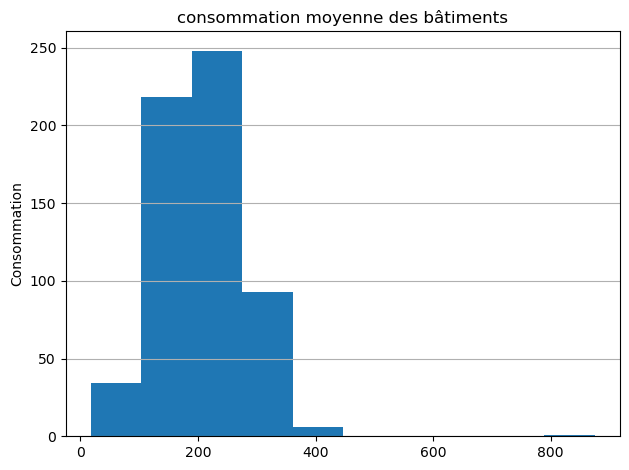

In [11]:
plt.figure()

plt.hist(df['consommation'], bins = 10) # Avec 10 classes
plt.grid(axis = 'y')
plt.ylabel('Consommation')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

##### b) Modification du nombre de classes à 30

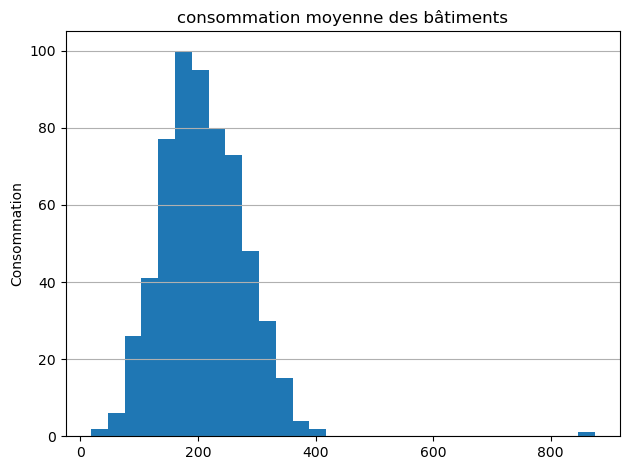

In [12]:
plt.figure()

plt.hist(df['consommation'], bins = 30) # Avec 30 classes
plt.grid(axis = 'y')
plt.ylabel('Consommation')
plt.title("consommation moyenne des bâtiments")

plt.tight_layout()
plt.show()

##### c) Impact le nombre de classes a-t-il sur l'interprétation ? 

#### Partie 4 – Nuage de points (Scatter Plot)  

##### 1) Réalisons un nuage de points entre température et consommation

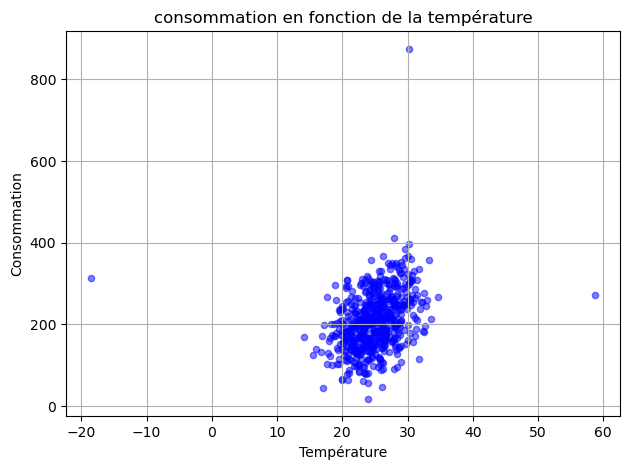

In [14]:
plt.figure()

plt.scatter(df['temperature'], df['consommation'], c = 'b', alpha=0.5, s=20)
plt.grid()
plt.xlabel('Température')
plt.ylabel('Consommation')
plt.title("consommation en fonction de la température")

plt.tight_layout()
plt.show()

##### 2) Déterminons visuellement s'il semble exister une relation entre les deux 

Visuellement on remarque qu'il y'a une relation particuliere(semble linéaire) qui existe entre la température et la consommation d'energie